In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("combined_data.csv")
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [3]:
df.shape

(83448, 2)

In [4]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['label'].value_counts()

label
1    43910
0    39538
Name: count, dtype: int64

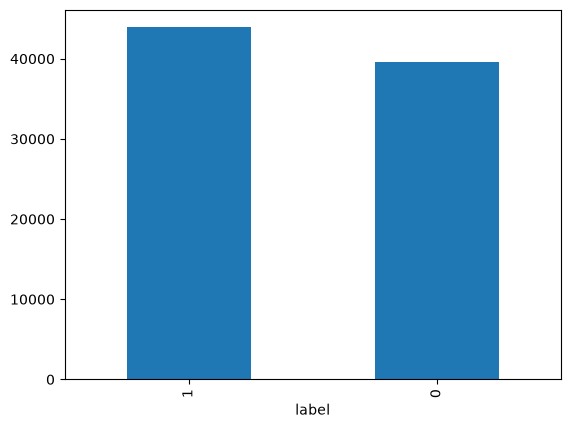

In [7]:
df['label'].value_counts().plot(kind='bar')
plt.show()

In [8]:
## Remove Punctuation
df['text'] = df['text'].str.replace(r'[^\w\s]', '', regex=True)

In [17]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/himmat/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [18]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['text'] = df['text'].apply(
    lambda x: ' '.join(w for w in x.split() if w not in stop_words)
)

In [19]:
## Remove numbers
df['text'] = df['text'].str.replace(r'\d+', '', regex=True)

In [20]:
import re
import emoji

def emojis_to_text(text):
    emoji_text = emoji.demojize(text, language='en')
    emoji_text = emoji_text.replace(":", " ")  # remove colon safely
    emoji_text = emoji_text.replace("_", " ")  # keep words readable
    return re.sub(r'\s+', ' ', emoji_text).strip()

df['text'] = df['text'].apply(emojis_to_text)

In [21]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...


In [22]:
x = df['text']
y = df['label']

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,1)
)

In [25]:
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_val)

In [27]:
from emailClassifier.utils.mlflow_manager import configure_mlflow

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

In [28]:
configure_mlflow(experiment_name="Ensemble learning")

[2026-10-09 11:58:15,927: INFO: _client: HTTP Request: GET https://dagshub.com/api/v1/user "HTTP/1.1 200 OK"]
Accessing as HimmatMagar
[2026-10-09 11:58:15,955: INFO: helpers: Accessing as HimmatMagar]
[2026-10-09 11:58:28,112: INFO: _client: HTTP Request: GET https://dagshub.com/api/v1/repos/HimmatMagar/Email_Spam_Classifier "HTTP/1.1 200 OK"]
[2026-10-09 11:58:29,016: INFO: _client: HTTP Request: GET https://dagshub.com/api/v1/user "HTTP/1.1 200 OK"]
Initialized MLflow to track repo "HimmatMagar/Email_Spam_Classifier"
[2026-10-09 11:58:29,019: INFO: helpers: Initialized MLflow to track repo "HimmatMagar/Email_Spam_Classifier"]
Repository HimmatMagar/Email_Spam_Classifier initialized!
[2026-10-09 11:58:29,020: INFO: helpers: Repository HimmatMagar/Email_Spam_Classifier initialized!]


2026/10/09 11:58:38 INFO mlflow.tracking.fluent: Experiment with name 'Ensemble learning' does not exist. Creating a new experiment.


Mlflow -> Dagshub | Experiment: Ensemble learning


In [29]:
import mlflow

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [31]:
models = {
    "random-forest": RandomForestClassifier(random_state=42),
    "adaboost": AdaBoostClassifier(random_state=42),
}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(x_train_tfidf, y_train)

        y_pred = model.predict(x_test_tfidf)

        metrics = {
            "accuracy": accuracy_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred, zero_division=0),
            "recall": recall_score(y_val, y_pred, zero_division=0),
            "f1": f1_score(y_val, y_pred, zero_division=0),
        }

        mlflow.log_params(model.get_params())
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, name="model")

        print(f"{name}: {metrics}")

2026/10/09 12:02:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


random-forest: {'accuracy': 0.976952266826443, 'precision': 0.9725150602409639, 'recall': 0.9838500799878114, 'f1': 0.9781497330253341}
🏃 View run random-forest at: https://dagshub.com/HimmatMagar/Email_Spam_Classifier.mlflow/#/experiments/22/runs/e85954e515044b31bd436966060aa4c9
🧪 View experiment at: https://dagshub.com/HimmatMagar/Email_Spam_Classifier.mlflow/#/experiments/22


2026/10/09 12:02:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


adaboost: {'accuracy': 0.8748152586379069, 'precision': 0.8323687886649371, 'recall': 0.9532261750590386, 'f1': 0.8887073863636363}
🏃 View run adaboost at: https://dagshub.com/HimmatMagar/Email_Spam_Classifier.mlflow/#/experiments/22/runs/d010941a21164e45a03d990becdc8894
🧪 View experiment at: https://dagshub.com/HimmatMagar/Email_Spam_Classifier.mlflow/#/experiments/22


In [36]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [20, 30, 40, 50],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6]
}

with mlflow.start_run(run_name="random-forest-tuning"):

    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=4,
        scoring="f1",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    random_search.fit(x_train_tfidf, y_train)

    best_model = random_search.best_estimator_

    y_pred = best_model.predict(x_test_tfidf)

    metrics = {
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0)
    }

    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("best_cv_f1", random_search.best_score_)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(best_model, name="model")

    print("Best parameters:", random_search.best_params_)
    print("Best CV F1:", random_search.best_score_)
    print("Test metrics:", metrics)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


2026/10/09 12:48:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Best parameters: {'n_estimators': 30, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None}
Best CV F1: 0.9761250511994698
Test metrics: {'accuracy': 0.9751547833033752, 'precision': 0.970148131438454, 'recall': 0.9828597547040451, 'f1': 0.9764625747370015}
🏃 View run random-forest-tuning at: https://dagshub.com/HimmatMagar/Email_Spam_Classifier.mlflow/#/experiments/22/runs/5c21882e0f02482e84db4ea547210a21
🧪 View experiment at: https://dagshub.com/HimmatMagar/Email_Spam_Classifier.mlflow/#/experiments/22


In [25]:
import optuna
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

In [20]:
def objective(trial):

      classifier_name = trial.suggest_categorical("classifier", ['SVC', 'MultinomialNB', 'LogisticRegression'])
      if classifier_name == "SVC":
            c = trial.suggest_float("C", 0.1, 100, log=True)
            kernel = trial.suggest_categorical("kernel", ['linear', 'rbf', 'poly', 'sigmoid'])
            gamma = trial.suggest_categorical("gamma", ['scale', 'auto'])

            model = SVC(
                  C=c,
                  kernel=kernel,
                  gamma=gamma,
                  class_weight='balanced'
            )
            
      elif classifier_name == "LogisticRegression":
            l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)
            c = trial.suggest_float("C", 0.1, 100, log=True)

            model = LogisticRegression(
                  l1_ratio=l1_ratio,
                  solver='saga',
                  C=c,
                  class_weight='balanced',
                  max_iter=1000
            )
            
      elif classifier_name == "MultinomialNB":
            alpha = trial.suggest_float("alpha", 1.0, 5.0, step=1.0)
            force_alpha = trial.suggest_categorical("force_alpha", [True, False])

            model = MultinomialNB(
                  alpha=alpha,
                  force_alpha=force_alpha
            )
            
      score = cross_val_score(model, x_train_tfidf, y_train, cv=3, scoring="accuracy").mean()
      return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5, show_progress_bar=True)

[I 2026-03-20 20:22:30,132] A new study created in memory with name: no-name-16604e2b-366b-44d2-aa43-3f8b1b13726b
Best trial: 0. Best value: 0.966908:  20%|██        | 1/5 [00:09<00:39,  9.91s/it]

[I 2026-03-20 20:22:40,052] Trial 0 finished with value: 0.9669080512899525 and parameters: {'classifier': 'LogisticRegression', 'l1_ratio': 0.7107499823997622, 'C': 0.8102408803710128}. Best is trial 0 with value: 0.9669080512899525.


Best trial: 1. Best value: 0.967473:  40%|████      | 2/5 [02:02<03:30, 70.19s/it]

[I 2026-03-20 20:24:32,420] Trial 1 finished with value: 0.9674729940253025 and parameters: {'classifier': 'LogisticRegression', 'l1_ratio': 0.8671320082420998, 'C': 11.229811499805514}. Best is trial 1 with value: 0.9674729940253025.


Best trial: 2. Best value: 0.979474:  60%|██████    | 3/5 [20:17<17:56, 538.23s/it]

[I 2026-03-20 20:42:47,610] Trial 2 finished with value: 0.9794737472822831 and parameters: {'classifier': 'SVC', 'C': 1.3395401527349577, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.9794737472822831.


Best trial: 2. Best value: 0.979474:  80%|████████  | 4/5 [29:20<09:00, 540.03s/it]

[I 2026-03-20 20:51:50,428] Trial 3 finished with value: 0.9679865783301662 and parameters: {'classifier': 'LogisticRegression', 'l1_ratio': 0.998079595070938, 'C': 6.9673147786530025}. Best is trial 2 with value: 0.9794737472822831.


Best trial: 2. Best value: 0.979474: 100%|██████████| 5/5 [51:34<00:00, 618.89s/it]

[I 2026-03-20 21:14:04,504] Trial 4 finished with value: 0.9699895571191345 and parameters: {'classifier': 'SVC', 'C': 0.11429197112067385, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.9794737472822831.


In [27]:
lr = SVC(
      C=1.33,
      kernel='rbf',
      gamma='scale',
      class_weight='balanced'
)

In [28]:
lr.fit(x_train_tfidf, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.33
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
yPred = lr.predict(x_test_tfidf)
print("/n", classification_report(y_val, yPred))

/n               precision    recall  f1-score   support

           0       0.99      0.97      0.98     11854
           1       0.98      0.99      0.98     13181

    accuracy                           0.98     25035
   macro avg       0.98      0.98      0.98     25035
weighted avg       0.98      0.98      0.98     25035

